# 00 Runbook

Unified operator + exploration notebook for wearable sessions.

This notebook is client-side only: trigger pipeline, monitor run state, sync local copies, and explore artifacts.

## A. Setup

In [1]:
from pathlib import Path
import json
import logging
import os
import sys

NOTEBOOK_ROOT = Path.cwd()
EXPECTED_PYTHON = (NOTEBOOK_ROOT / ".venv" / "bin" / "python").resolve()
CURRENT_PYTHON = Path(sys.executable).resolve()

# Avoid matplotlib cache permission issues in restricted environments.
os.environ.setdefault("MPLCONFIGDIR", str((NOTEBOOK_ROOT / ".mplconfig").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

if CURRENT_PYTHON != EXPECTED_PYTHON:
    raise RuntimeError(
        "Wrong Jupyter kernel selected.\n"
        f"Expected: {EXPECTED_PYTHON}\n"
        f"Current:  {CURRENT_PYTHON}\n"
        "Select kernel: Python (homelab notebooks) and restart Run All."
    )

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

LIB_PATH = NOTEBOOK_ROOT / "lib"
if str(LIB_PATH) not in sys.path:
    sys.path.insert(0, str(LIB_PATH))

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(name)s %(message)s")
load_dotenv(NOTEBOOK_ROOT / ".env")
sns.set_theme(style="whitegrid")

from pipeline_client import run_full_pipeline
from remote_sync import get_latest_session, get_session_by_id, list_sessions
from session_loader import load_clean, load_raw_chunks, load_summary, load_window_features



In [2]:
# Runtime parameters
user_id = 2
session_id = None      # Set explicit session id, e.g. "session-001"
use_latest = True      # True -> pick latest discovered session

# Data loading safety limits
max_clean_rows_per_stream = 50_000
max_feature_rows_per_stream = 50_000
raw_preview_rows_per_stream = 20
raw_max_scan_lines = 20_000


## B. Session Discovery

In [3]:
sessions = list_sessions(user_id=user_id, env_path=NOTEBOOK_ROOT / ".env")
print(f"Discovered {len(sessions)} sessions for user_id={user_id}")

session_table = pd.DataFrame(
    [
        {
            "session_id": s["session_id"],
            "streams": ",".join(s.get("available_streams", [])),
            "dates": ",".join(s.get("dates", [])),
        }
        for s in sessions
    ]
)
session_table


2026-04-26 14:03:11,041 INFO remote_sync ssh_command_start
2026-04-26 14:03:11,547 INFO remote_sync ssh_command_success
2026-04-26 14:03:11,550 INFO remote_sync ssh_command_start
2026-04-26 14:03:11,802 INFO remote_sync ssh_command_success
2026-04-26 14:03:11,803 INFO remote_sync ssh_command_start
2026-04-26 14:03:12,199 INFO remote_sync ssh_command_success
2026-04-26 14:03:12,200 INFO remote_sync ssh_command_start
2026-04-26 14:03:12,498 INFO remote_sync ssh_command_success
2026-04-26 14:03:12,499 INFO remote_sync session_discovery_mode
2026-04-26 14:03:12,500 INFO remote_sync ssh_command_start
2026-04-26 14:03:12,882 INFO remote_sync ssh_command_success
2026-04-26 14:03:12,883 INFO remote_sync ssh_command_start
2026-04-26 14:03:13,259 INFO remote_sync ssh_command_success
2026-04-26 14:03:13,262 INFO remote_sync ssh_command_start
2026-04-26 14:03:13,796 INFO remote_sync ssh_command_success
2026-04-26 14:03:13,797 INFO remote_sync ssh_command_start
2026-04-26 14:03:14,242 INFO remote_s

Discovered 2 sessions for user_id=2


,session_id,streams,dates
0,c93f6d22-4edd-44f7-8749-cda389364255,hr,2026-04-26
1,401be561-180a-4bf4-9c57-83591ba7e455,hr,2026-04-26


In [4]:
if not sessions:
    raise ValueError(f"No sessions found for user_id={user_id}")

if use_latest:
    selected = sessions[0]
elif session_id:
    selected = next((s for s in sessions if s["session_id"] == session_id), None)
    if selected is None:
        raise ValueError(f"Requested session_id={session_id} not found")
else:
    raise ValueError("Set use_latest=True or provide session_id")

selected_session_id = selected["session_id"]
print("Selected session:", selected_session_id)
print("Available streams:", selected.get("available_streams", []))


Selected session: c93f6d22-4edd-44f7-8749-cda389364255
Available streams: ['hr']


## C. Run Pipeline

In [5]:
pipeline_result = run_full_pipeline(
    session_id=selected_session_id,
    user_id=user_id,
    env_path=NOTEBOOK_ROOT / ".env",
    poll_interval_seconds=3.0,
    live_progress=True,
)

pipeline_result.get("session_summaries", [])


2026-04-26 14:03:25,603 INFO pipeline_client pipeline_run_start
2026-04-26 14:03:25,605 INFO remote_sync ssh_command_start
2026-04-26 14:03:25,814 INFO remote_sync ssh_command_success
2026-04-26 14:03:25,816 INFO remote_sync ssh_command_start
2026-04-26 14:03:26,043 INFO remote_sync ssh_command_success
2026-04-26 14:03:26,044 INFO remote_sync ssh_command_start
2026-04-26 14:03:26,449 WARNING remote_sync ssh_command_failed
2026-04-26 14:03:28,454 INFO remote_sync ssh_command_start
2026-04-26 14:03:28,871 WARNING remote_sync ssh_command_failed
2026-04-26 14:03:30,878 INFO remote_sync ssh_command_start
2026-04-26 14:03:31,456 WARNING remote_sync ssh_command_failed
2026-04-26 14:03:31,459 WARNING pipeline_client pipeline_progress_poll_failed
2026-04-26 14:03:34,465 INFO pipeline_client pipeline_run_finished


Final step summary:
[normalize] status=success streams: success=1 skipped=0 failed=0
[window_features] status=success streams: success=1 skipped=0 failed=0
[build_session_summary] status=success streams: success=1 skipped=0 failed=0


[{'run_id': '3e7d809625014eeb99c74bd5dc43fea4',
  'step_name': 'normalize',
  'status': 'success',
  'session_id': 'c93f6d22-4edd-44f7-8749-cda389364255',
  'stream_success': 1,
  'stream_skipped': 0,
  'stream_failed': 0,
  'stream_statuses': ['hr:success'],
  'warnings': [],
  'state_path': '/data/wearable/pipeline_runs/normalize/3e7d809625014eeb99c74bd5dc43fea4.json'},
 {'run_id': 'e489acb84c0c46c79aae698ed9517c9b',
  'step_name': 'window_features',
  'status': 'success',
  'session_id': 'c93f6d22-4edd-44f7-8749-cda389364255',
  'stream_success': 1,
  'stream_skipped': 0,
  'stream_failed': 0,
  'stream_statuses': ['hr:success'],
  'warnings': [],
  'state_path': '/data/wearable/pipeline_runs/window_features/e489acb84c0c46c79aae698ed9517c9b.json'},
 {'run_id': '1f65bfd60c984fdeaecaae280204aab2',
  'step_name': 'build_session_summary',
  'status': 'success',
  'session_id': 'c93f6d22-4edd-44f7-8749-cda389364255',
  'stream_success': 1,
  'stream_skipped': 0,
  'stream_failed': 0,
  '

## D. Sync Data

In [6]:
session_cache_path = get_session_by_id(
    user_id=user_id,
    session_id=selected_session_id,
    local_cache_root=NOTEBOOK_ROOT / "data_cache",
    env_path=NOTEBOOK_ROOT / ".env",
)
print("Local cache path:", session_cache_path)


2026-04-26 14:03:34,481 INFO remote_sync ssh_command_start
2026-04-26 14:03:34,764 INFO remote_sync ssh_command_success
2026-04-26 14:03:34,766 INFO remote_sync ssh_command_start
2026-04-26 14:03:35,025 INFO remote_sync ssh_command_success
2026-04-26 14:03:35,026 INFO remote_sync ssh_command_start
2026-04-26 14:03:35,345 INFO remote_sync ssh_command_success
2026-04-26 14:03:35,347 INFO remote_sync ssh_command_start
2026-04-26 14:03:35,602 INFO remote_sync ssh_command_success
2026-04-26 14:03:35,604 INFO remote_sync session_discovery_mode
2026-04-26 14:03:35,604 INFO remote_sync session_sync_start
2026-04-26 14:03:35,605 INFO remote_sync sync_start
2026-04-26 14:03:36,028 INFO remote_sync sync_success
2026-04-26 14:03:36,029 INFO remote_sync sync_start
2026-04-26 14:03:36,329 INFO remote_sync sync_success
2026-04-26 14:03:36,330 INFO remote_sync sync_start
2026-04-26 14:03:37,102 INFO remote_sync sync_success
2026-04-26 14:03:37,104 INFO remote_sync session_sync_finished


Local cache path: /Users/maksymponomarenko/Documents/homelab/notebooks/data_cache/session_id=c93f6d22-4edd-44f7-8749-cda389364255


## E. Summary View

In [7]:
summary = load_summary(session_cache_path)
if summary:
    print(json.dumps(summary, indent=2, ensure_ascii=False))
else:
    print("No session_summary.json found")


2026-04-26 14:03:37,115 INFO session_loader summary_loaded


{
  "schema_version": "1.0",
  "generated_at_utc": "2026-04-26T11:03:26.276560Z",
  "session_id": "c93f6d22-4edd-44f7-8749-cda389364255",
  "inputs": {
    "window_feature_paths": [
      "/data/wearable/processed/window_features/user_id=2/source=polar_verity_sense/session_id=c93f6d22-4edd-44f7-8749-cda389364255/streams/hr/data.parquet"
    ],
    "available_window_sizes": [
      "30s",
      "1m",
      "5m"
    ]
  },
  "streams": {
    "hr": {
      "status": "success",
      "coverage": {
        "window_counts": {
          "30s": 342,
          "1m": 172,
          "5m": 35
        },
        "estimated_duration_seconds": 10260
      },
      "hr_statistics": {
        "min": 54.166666666666664,
        "max": 90.86666666666666,
        "mean": 66.64817251461989,
        "median": 65.1,
        "std": 7.6059449181491585,
        "p05": 56.711666666666666,
        "p10": 57.77333333333333,
        "p90": 77.82333333333334,
        "p95": 82.61999999999999,
        "range": 36.699

In [8]:
def _pick(dct, *paths):
    for path in paths:
        node = dct
        ok = True
        for key in path:
            if isinstance(node, dict) and key in node:
                node = node[key]
            else:
                ok = False
                break
        if ok:
            return node
    return None

if summary:
    key_rows = [
        {"field": "duration_seconds", "value": _pick(summary, ["duration_seconds"], ["duration", "seconds"])},
        {"field": "hr_mean", "value": _pick(summary, ["hr", "mean"], ["stats", "hr", "mean"])},
        {"field": "hr_min", "value": _pick(summary, ["hr", "min"], ["stats", "hr", "min"])},
        {"field": "hr_max", "value": _pick(summary, ["hr", "max"], ["stats", "hr", "max"])},
        {"field": "data_quality", "value": _pick(summary, ["data_quality"], ["quality"])},
        {"field": "warnings", "value": _pick(summary, ["warnings"])},
    ]
    pd.DataFrame(key_rows)


## F. Window Features View

In [9]:
window_features = load_window_features(
    session_cache_path,
    max_rows_per_stream=max_feature_rows_per_stream,
)

rows = []
for stream_type, df in window_features.items():
    ws_col = None
    for candidate in ["window_size_seconds", "window_size_sec", "window_sec", "window_size"]:
        if candidate in df.columns:
            ws_col = candidate
            break
    if ws_col:
        by_size = df[ws_col].value_counts(dropna=False).to_dict()
    else:
        by_size = {"unknown": len(df)}
    rows.append({
        "stream_type": stream_type,
        "row_count": len(df),
        "window_sizes": by_size,
        "columns": list(df.columns),
    })

pd.DataFrame(rows)


2026-04-26 14:03:37,164 INFO session_loader window_features_loaded


,stream_type,row_count,window_sizes,columns
0,hr,549,"{'30s': 342, '1m': 172, '5m': 35}","[user_id, session_id, stream_id, stream_type, ..."


In [10]:
def _pick_column(columns, candidates):
    lookup = {str(c).lower(): str(c) for c in columns}
    for candidate in candidates:
        if candidate.lower() in lookup:
            return lookup[candidate.lower()]
    return None

for stream_type, df in window_features.items():
    if df.empty:
        continue

    ts_col = _pick_column(df.columns, ["window_start_ts", "window_start", "ts_utc", "timestamp"])
    mean_col = _pick_column(df.columns, ["mean_hr", "window_mean_hr", "hr_mean", "mean"])

    if ts_col and mean_col:
        plot_df = df.copy()
        plot_df[ts_col] = pd.to_datetime(plot_df[ts_col], errors="coerce")
        plot_df = plot_df.dropna(subset=[ts_col]).sort_values(ts_col)

        plt.figure(figsize=(11, 4))
        sns.lineplot(data=plot_df, x=ts_col, y=mean_col)
        plt.title(f"{stream_type}: Window Mean Trend")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()
    else:
        print(f"{stream_type}: no standard trend columns found (metadata-only view)")


hr: no standard trend columns found (metadata-only view)


## G. Clean Time-Series View

2026-04-26 14:03:37,193 INFO session_loader clean_loaded


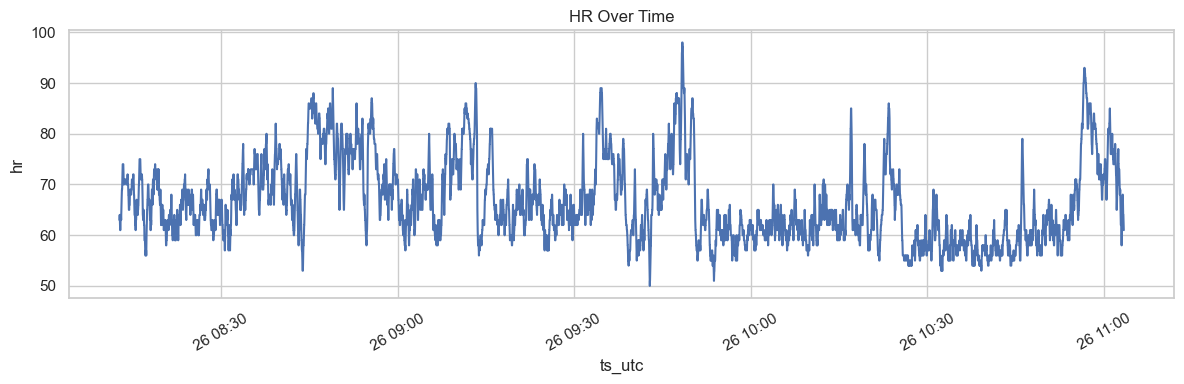

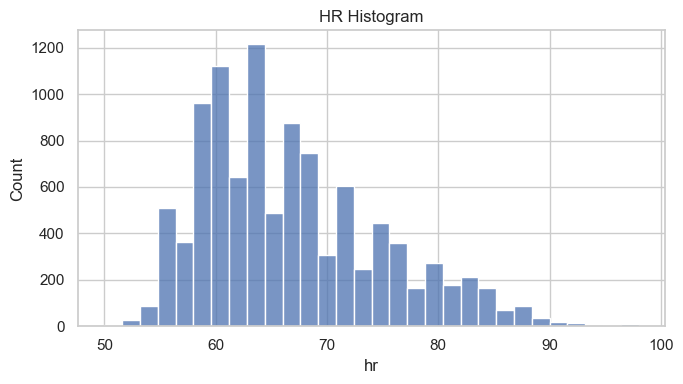

In [11]:
clean_streams = load_clean(
    session_cache_path,
    max_rows_per_stream=max_clean_rows_per_stream,
)

hr_df = clean_streams.get("hr")
if hr_df is None or hr_df.empty:
    print("No HR clean stream found")
else:
    ts_col = None
    hr_col = None
    for candidate in ["ts_utc", "timestamp", "received_at_collector"]:
        if candidate in hr_df.columns:
            ts_col = candidate
            break
    for candidate in ["hr", "heart_rate"]:
        if candidate in hr_df.columns:
            hr_col = candidate
            break

    if ts_col and hr_col:
        plot_df = hr_df.copy()
        plot_df[ts_col] = pd.to_datetime(plot_df[ts_col], errors="coerce")
        plot_df = plot_df.dropna(subset=[ts_col]).sort_values(ts_col)

        plt.figure(figsize=(12, 4))
        sns.lineplot(data=plot_df, x=ts_col, y=hr_col)
        plt.title("HR Over Time")
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(7, 4))
        sns.histplot(plot_df[hr_col].dropna(), bins=30)
        plt.title("HR Histogram")
        plt.tight_layout()
        plt.show()
    else:
        print("HR stream found, but expected columns are missing")


## H. Raw Data Debug View

In [12]:
raw_chunks = load_raw_chunks(
    session_cache_path,
    preview_rows_per_stream=raw_preview_rows_per_stream,
    max_scan_lines_per_stream=raw_max_scan_lines,
)

raw_rows = []
for stream_type, item in raw_chunks.items():
    raw_rows.append({
        "stream_type": stream_type,
        "preview_rows": item.get("preview_count"),
        "scanned_lines": item.get("scanned_lines"),
        "scan_truncated": item.get("scan_truncated"),
        "first_timestamp": item.get("first_timestamp"),
        "last_timestamp": item.get("last_timestamp"),
        "path": item.get("path"),
    })

pd.DataFrame(raw_rows)


2026-04-26 14:03:38,000 INFO session_loader raw_loaded


,stream_type,preview_rows,scanned_lines,scan_truncated,first_timestamp,last_timestamp,path
0,hr,20,512,False,2026-04-26T08:13:03.392413Z,2026-04-26T08:19:23.247001Z,/Users/maksymponomarenko/Documents/homelab/not...


In [14]:
for stream_type, item in sorted(raw_chunks.items()):
    preview = item.get("preview", [])
    first_chunk = preview[0] if preview else {}

    print(f"[{stream_type}] chunks path: {item.get('path')}")
    print(f"preview rows: {item.get('preview_count')} scanned lines: {item.get('scanned_lines')}")
    print("first chunk preview:")
    print(json.dumps(first_chunk, indent=2, ensure_ascii=False)[:2000])


[hr] chunks path: /Users/maksymponomarenko/Documents/homelab/notebooks/data_cache/session_id=c93f6d22-4edd-44f7-8749-cda389364255/data/wearable/raw/user_id=2/source=polar_verity_sense/date=2026-04-26/session_id=c93f6d22-4edd-44f7-8749-cda389364255/streams/hr/chunks.jsonl
preview rows: 20 scanned lines: 512
first chunk preview:
{
  "time": {
    "device_time_reference": "collector:collectorObserved",
    "first_sample_received_at_collector": "2026-04-26T08:12:44.058Z",
    "uploaded_at_collector": "2026-04-26T08:13:03.054Z"
  },
  "source": {
    "vendor": "polar",
    "device_model": "verity_sense",
    "device_id": "B15B5829"
  },
  "transport": {
    "payload_version": "1.0",
    "compression": "none",
    "payload_schema": "polar.hr",
    "encoding": "json"
  },
  "payload": {
    "samples": [
      {
        "contactStatus": false,
        "correctedHr": 0,
        "ppgQuality": 0,
        "rrsMs": [],
        "hr": 63,
        "received_at_collector": "2026-04-26T08:12:44.058Z",
 

## I. Multi-Stream Support

In [16]:
known_streams = {"hr"}
print("Known streams:", sorted(list(known_streams)))
print("Per-stream metadata summary:")

all_streams = sorted(set(clean_streams.keys()) | set(window_features.keys()) | set(raw_chunks.keys()))
for stream_type in all_streams:
    clean_rows = len(clean_streams.get(stream_type, pd.DataFrame()))
    win_rows = len(window_features.get(stream_type, pd.DataFrame()))
    raw_preview = raw_chunks.get(stream_type, {}).get("preview_count", 0)

    if stream_type in known_streams:
        print(f"- {stream_type}: clean_rows={clean_rows}, window_rows={win_rows}, raw_preview={raw_preview}")
    else:
        print(
            f"- {stream_type} (unknown stream): "
            f"clean_rows={clean_rows}, window_rows={win_rows}, raw_preview={raw_preview}"
        )

raw_set = set(raw_chunks.keys())
processed_set = set(clean_streams.keys()) | set(window_features.keys())

missing_raw = sorted(processed_set - raw_set)
missing_processed = sorted(raw_set - processed_set)

if missing_raw:
    print(f"WARNING: processed artifacts exist but raw is missing for: {missing_raw}")
if missing_processed:
    print(f"WARNING: raw exists but processed artifacts are missing for: {missing_processed}")
if not missing_raw and not missing_processed:
    print("Raw and processed stream sets are aligned")


Known streams: ['hr']
Per-stream metadata summary:
- hr: clean_rows=10240, window_rows=549, raw_preview=20
Raw and processed stream sets are aligned
